# import pips

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    'valid',                    # Path to validation folder
    label_mode='categorical',   # Multi-class (4 classes → one-hot)
    image_size=(224, 224),      # Resize images
    batch_size=32,              # 32 images per batch
    shuffle=False               # No need to shuffle validation data
)

Found 761 files belonging to 4 classes.


In [3]:
class_name = valid_data.class_names
class_name

['NORMAL', 'PNEUMONIA', 'TUBERCULOSIS', 'UNKNOWN']

# Load Fusion Model

In [4]:
fusion = tf.keras.models.load_model("x_ray.keras", compile=False)

visual Image

<>:3: SyntaxWarning: invalid escape sequence '\A'
<>:3: SyntaxWarning: invalid escape sequence '\A'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2664\3158726493.py:3: SyntaxWarning: invalid escape sequence '\A'
  image_path = 'test\Aw.jpg'


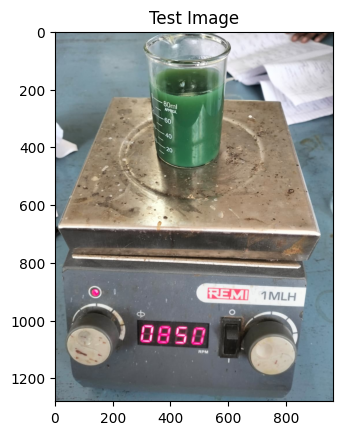

In [6]:
#Test Image Visualization
import cv2
image_path = 'test\Aw.jpg'
# Reading an image in default mode
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Converting BGR to RGB
img_resized = cv2.resize(img, (224, 224))
img_norm = img_resized / 255.0
input_img = np.expand_dims(img_norm, axis=0)
# Displaying the image 
plt.imshow(img)
plt.title('Test Image')

plt.show()

Test Model

In [7]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(224,224))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = fusion.predict(input_arr)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


In [8]:
print(predictions)

[[5.8814488e-11 3.6478608e-13 1.0370324e-12 1.0000000e+00]]


In [9]:
result_index = np.argmax(predictions) #Return index of max element
print(result_index)

3


In [10]:
last_conv_layer_name = "conv5_block3_out" 

In [11]:
grad_model = tf.keras.models.Model(
    [fusion.inputs],
    [fusion.get_layer(last_conv_layer_name).output, fusion.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_img)
    loss = predictions[:, result_index]

grads = tape.gradient(loss, conv_outputs)

# Global average pooling
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize heatmap
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


In [12]:
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

In [13]:
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

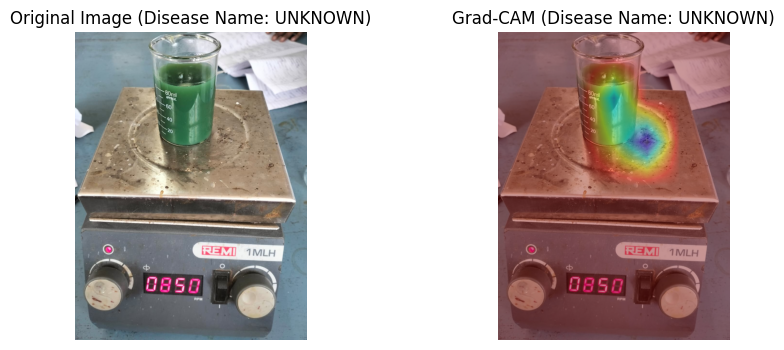

Disease Name: UNKNOWN


In [14]:
model_prediction = class_name[result_index]
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title(f"Original Image (Disease Name: {model_prediction})")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(superimposed_img)
plt.title(f"Grad-CAM (Disease Name: {model_prediction})")
plt.axis('off')

plt.show()

print(f"Disease Name: {model_prediction}")